### Telco Customer Churn EDA
Customer Churn occurs when customers or subscribers stop doing business with a company or service. A company that has a high churn rate is losing a significant amount of revenue, as acquiring new customers often costs more than retaining existing ones.

### 1.Import Libraries

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    )
import shap
import joblib
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

The dataset used in this project is the Telco Customer Churn dataset, which contains information about customers, including their demographics, services used, and billing details. 

This dataset was chosen because it represents a realistic business problem where companies aim to predict which customers are likely to leave their service. Understanding this behaviour is important as customer retention is often more cost-effective than acquiring new customers.

The dataset is loaded into a Pandas DataFrame, which allows efficient manipulation and analysis of the data throughout the project.

### 2. Load Dataset


In [75]:
df = pd.read_csv(r"C:\Users\Brandon\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Inspect data
print(df.head())
print(df.info())

# Initial inspection is important to understand the structure of the dataset,
# identify missing values, and determine which features may need preprocessing.


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No        

### 3. Initial Data Inspection

Initial Data Inspection

Before performing any analysis, it is important to understand the structure of the dataset. This includes checking the number of rows and columns, data types, and identifying any missing values.

This step helps identify potential issues such as incorrect data types or incomplete data, which could negatively impact the performance of machine learning models if not addressed early.

In [76]:
df.shape

(7043, 21)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [78]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 4.Data Cleaning

Data Cleaning

Data cleaning is an important step in preparing the dataset for analysis. In this project, the `TotalCharges` column is converted to a numeric format because it was originally stored as text. This ensures that it can be used correctly in calculations and modelling.

Rows with missing values are removed to prevent errors during model training. While removing data can reduce the dataset size slightly, it ensures that the remaining data is consistent and reliable.

This step improves the overall quality of the dataset and helps ensure that the models are trained on valid data.

In [79]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna(subset=['TotalCharges'])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (7032, 21)


### 5. Exploratory Data Analysis(EDA)

Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand patterns and relationships within the dataset. Visualisations such as count plots and distributions are used to examine how features relate to customer churn.

For example, analysing the distribution of churn helps identify whether the dataset is balanced or imbalanced. This is important because class imbalance can affect how well machine learning models perform.

EDA provides insight into which features may be important for predicting churn and helps guide the selection of models and features later in the project.

### 5.1 Churn Distribution

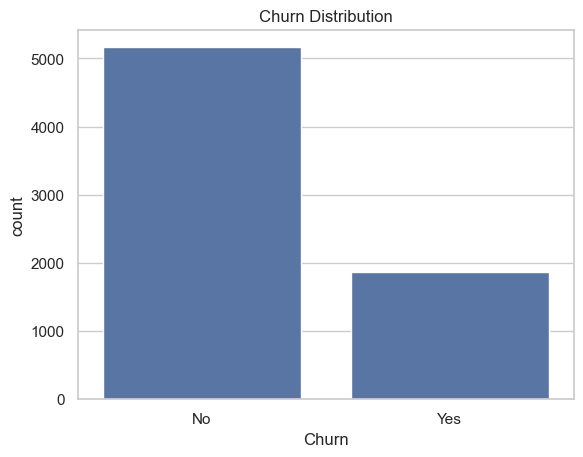

In [80]:
sns.countplot(x=df['Churn'])
plt.title("Churn Distribution")
plt.show()

### 5.2 Tenure vs Chrun

### Tenure 
how long a customer has been with the company

In the Telco Customer Churn dataset:

tenure is the number of months a customer has stayed with the company

So:

tenure = 1 → customer joined last month

tenure = 12 → customer has been with the company 1 year

tenure = 60 → customer has been with the company 5 years

### Churn
  when a customer stops using a company’s product or service

In simple terms:

A churned customer has left the company.

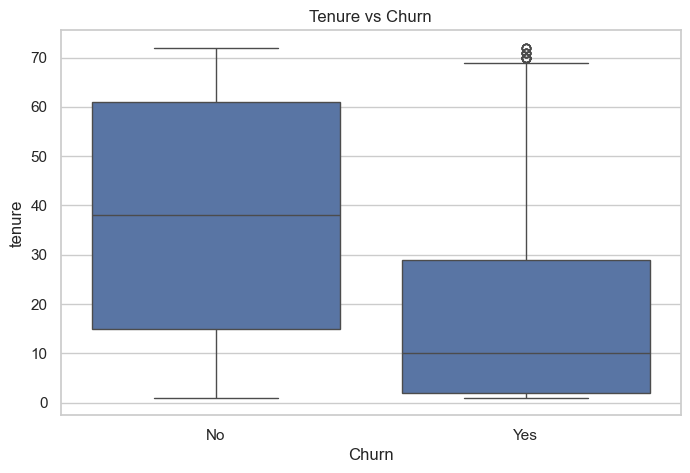

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert tenure to numeric (safe)
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['Churn', 'tenure'])

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title("Tenure vs Churn")
plt.show()


### 5.3 Monthly Charges vs Churn


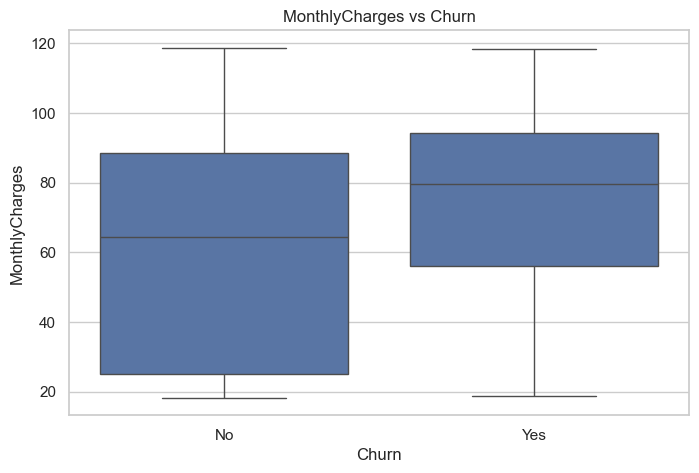

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Churn'], y=df['MonthlyCharges'])
plt.title("MonthlyCharges vs Churn")
plt.show()

### 5.4 Contract Vs Churn

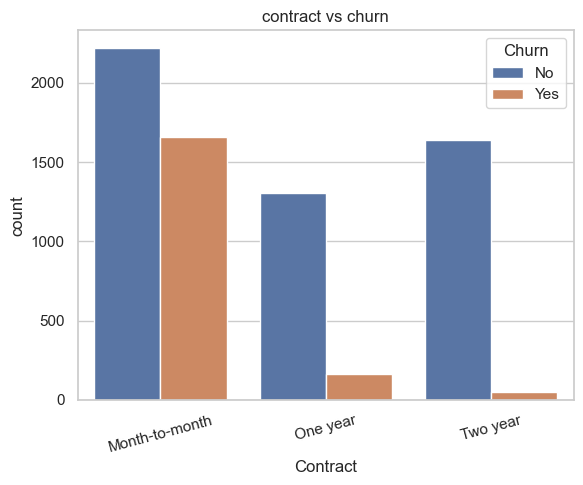

In [83]:
sns.countplot(x=df['Contract'], hue=df['Churn'])
plt.title("contract vs churn")
plt.xticks(rotation=15)
plt.show()

### 6.Feature Engineering

Feature engineering involves creating new variables that may improve the model’s ability to detect patterns. In this project, additional features such as average charges per month are created to better represent customer behaviour.

This helps the model capture relationships that may not be immediately visible from the original dataset, potentially improving prediction accuracy.

In [84]:
# ==============================
# FEATURE ENGINEERING
# ==============================

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# Create new feature
df['AvgChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Separate target
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop target and customer ID
X = df.drop(['Churn', 'customerID'], axis=1)

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (7032, 31)
Final y shape: (7032,)


This step prepares the dataset for machine learning. The Churn column is used as the target variable because the aim of the project is to predict whether a customer is likely to leave the company. It is converted into binary values so that classification models can process it more easily.

The customerID column is removed because it is only a unique label for each customer and does not represent meaningful behaviour. If it were kept, it could create unnecessary features during encoding and reduce the clarity of the analysis.

Rows with missing target values are removed to make sure the model is trained using complete and valid data. This helps prevent errors later in the workflow and improves the reliability of the results.

### 7.Train-Test Split and Scaling

The dataset is split into training and testing sets to evaluate model performance fairly. The training set is used to train the model, while the testing set is used to assess how well the model performs on unseen data.

An 80/20 split is used, which provides a good balance between training data and evaluation data. Ensures that the proportion of churn and non-churn customers remains consistent in both sets. This is important because the dataset is slightly imbalanced.

A fixed random state is used to ensure that results are reproducible.

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5625, 31)
Test shape: (1407, 31)


### 8.Model Training & Hyperparamerter Tuning

### What is Model Training?

It teaching a machine-learning algorithm to learn patterns from data.

In this churn project:

Input (X) → customer features (tenure, charges, contract, etc.)

Output (y) → Churn (0 = No, 1 = Yes)

The model learns:

“Customers with these characteristics are more likely to churn.”

### What are Hyperparameters?

Hyperparameters are settings you choose before training.

Examples:

Logistic Regression → C

Random Forest → n_estimators, max_depth

XGBoost → learning_rate, max_depth

They control how the model learns, not what it learns.

### What is Hyperparameter Tuning?

It systematically trying different settings and choosing the best one.

We do this because:

Default parameters are rarely optimal

Better parameters → better performance


### 8.1 Logistic Regression



Logistic Regression is used as a baseline model because it is simple, efficient, and easy to interpret. It provides a good starting point for comparison with more complex models.

This model estimates the probability that a customer will churn based on the input features. It is useful for understanding general patterns in the data, even if it may not capture complex relationships as effectively as other models.

In [86]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Stratified k-fold for reliability
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline: scaling + logistic regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

print("Best Logistic Regression Params:", lr_grid.best_params_)
print("Best Logistic Regression CV ROC-AUC:", lr_grid.best_score_)




Best Logistic Regression Params: {'model__C': 10, 'model__solver': 'liblinear'}
Best Logistic Regression CV ROC-AUC: 0.8497234526711314


### 8.2. Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions. This allows it to capture more complex relationships in the data compared to Logistic Regression.

It is included in this project to compare its performance against simpler models and to evaluate whether a more advanced approach improves prediction accuracy.

In [87]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": randint(100, 401),
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5),
    "max_features": ["sqrt", "log2", None]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

print("Best Random Forest Params:", rf_random.best_params_)
print("Best Random Forest CV ROC-AUC:", rf_random.best_score_)

Best Random Forest Params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 287}
Best Random Forest CV ROC-AUC: 0.846360345623426


### 8.3 XGBoost

### What is XGBoost?

XGBoost is a more advanced machine learning algorithm that builds decision trees sequentially, where each new tree focuses on correcting errors made by the previous ones.

It is widely used in industry due to its strong performance on structured datasets. In this project, it is used to determine whether a more complex model can improve churn prediction compared to Logistic Regression and Random Forest.

### Why XGBoost is GREAT for Churn

Churn data usually has:

Non-linear relationships

Feature interactions

Mixed feature importance

XGBoost handles all of that better than Logistic Regression or Random Forest.

In [88]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": randint(100, 301),
    "learning_rate": uniform(0.01, 0.2),
    "max_depth": randint(3, 8),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=20,
    cv=cv,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_

print("Best XGBoost Params:", xgb_random.best_params_)
print("Best XGBoost CV ROC-AUC:", xgb_random.best_score_)

Best XGBoost Params: {'colsample_bytree': np.float64(0.9499584735208493), 'learning_rate': np.float64(0.04467293070155442), 'max_depth': 3, 'n_estimators': 263, 'subsample': np.float64(0.7546708263364187)}
Best XGBoost CV ROC-AUC: 0.8489399693894903


### 9.Define Model


In [89]:
models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}


### 10.Train Models

In [90]:
for name, model in models.items():
    model.fit(X_train, y_train)

print("All tuned models trained successfully!")


All tuned models trained successfully!


In [91]:
from sklearn.model_selection import cross_val_score
import pandas as pd

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV ROC-AUC": scores.mean(),
        "Std CV ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).round(3)

print("===== Cross-Validation Results =====")
print(cv_results_df)

===== Cross-Validation Results =====
                 Model  Mean CV ROC-AUC  Std CV ROC-AUC
0  Logistic Regression            0.850           0.004
1        Random Forest            0.846           0.004
2              XGBoost            0.849           0.004


### 11. Model Evaluation 

Model performance is evaluated using metrics such as accuracy, precision, recall, and ROC-AUC. These metrics provide different perspectives on how well the model is performing.

ROC-AUC is particularly useful because it measures the model’s ability to distinguish between customers who churn and those who do not. This is important in business contexts where correctly identifying churn is more valuable than overall accuracy.

Using multiple evaluation metrics ensures a more complete understanding of model performance.

In [92]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"======== {name} ========")
    print(classification_report(y_test, y_pred))

    roc = roc_auc_score(y_test, y_prob)
    print(f"{name} ROC-AUC: {roc:.3f}")
    print()

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (Churn=1)": report["1"]["precision"],
        "Recall (Churn=1)": report["1"]["recall"],
        "F1-score (Churn=1)": report["1"]["f1-score"],
        "ROC-AUC": roc
    })

results_df = pd.DataFrame(results).round(3)

print("===== Model Comparison Table =====")
print(results_df)



======== Logistic Regression ========
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

Logistic Regression ROC-AUC: 0.838

======== Random Forest ========
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Random Forest ROC-AUC: 0.837

======== XGBoost ========
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy        

<Figure size 500x400 with 0 Axes>

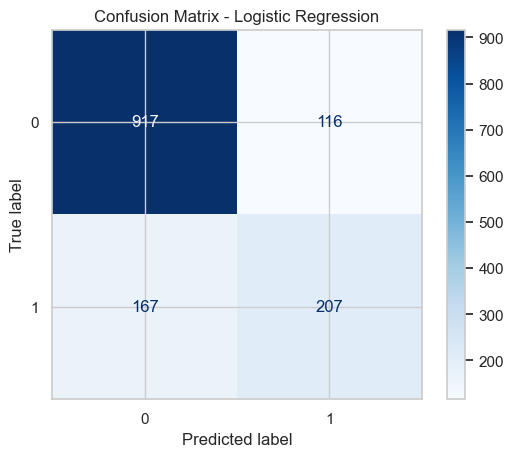

<Figure size 500x400 with 0 Axes>

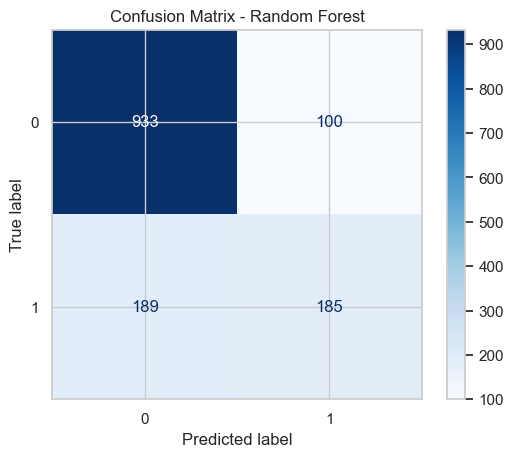

<Figure size 500x400 with 0 Axes>

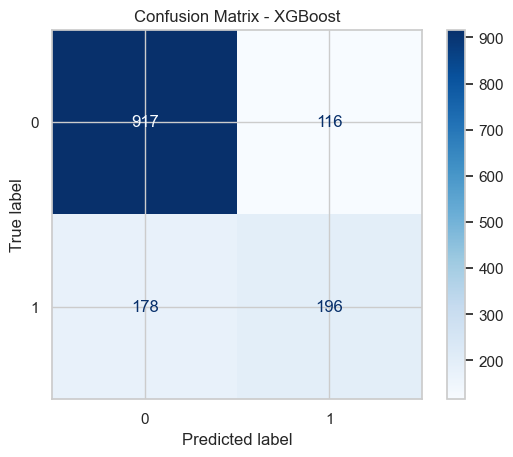

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

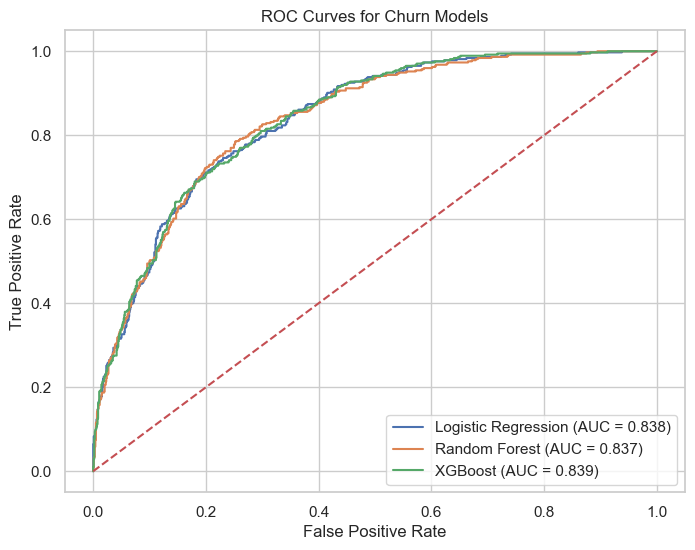

In [94]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Churn Models")
plt.legend()
plt.show()

### 12.Best Model Selection

In [95]:
best_model_name = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)


Best Model: XGBoost


### 13.SHAP  Interpretability
### What is SHAP Interpretability?

SHAP (SHapley Additive exPlanations) is used to explain how individual features influence the model’s predictions. Machine learning models, especially more complex ones like XGBoost, can act as “black boxes”, making it difficult to understand how decisions are made.

SHAP helps improve transparency by showing the contribution of each feature to the prediction. This is important in real-world applications, as businesses need to understand why a model is making certain decisions.

By using SHAP, this project not only focuses on prediction accuracy but also on making the model interpretable and more useful in a practical context.

Each feature “pays” part of the final prediction

SHAP tells you who paid how much

Positive SHAP value → increases churn
Negative SHAP value → decreases churn

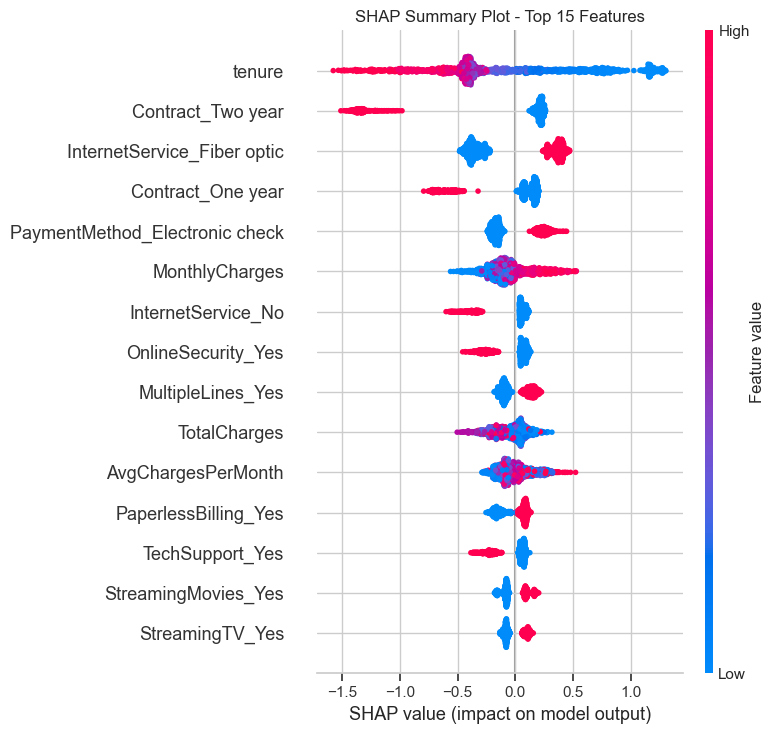

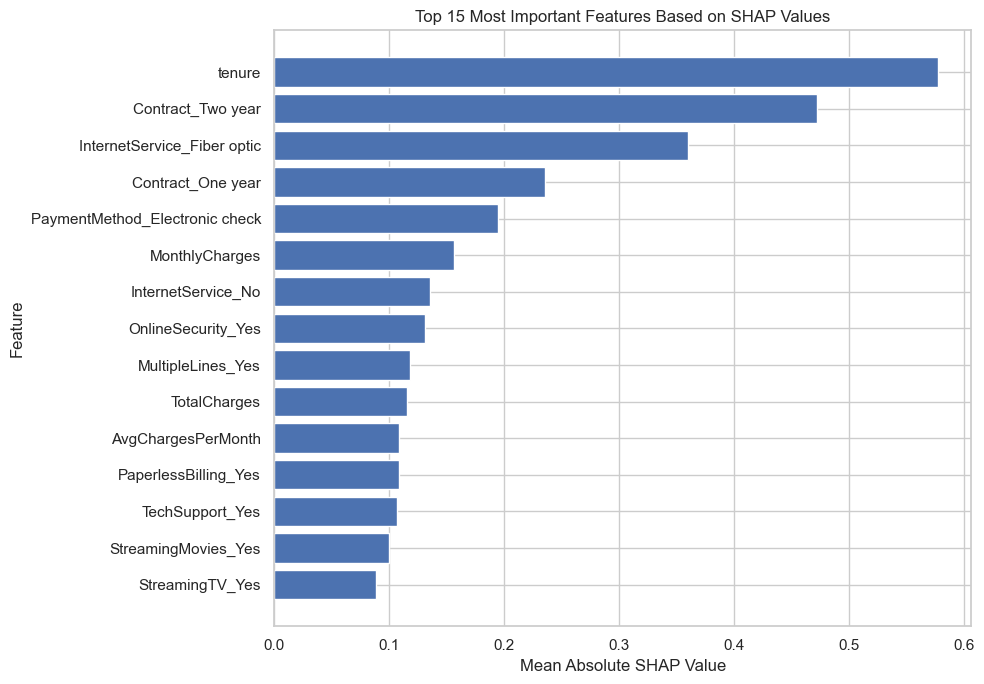

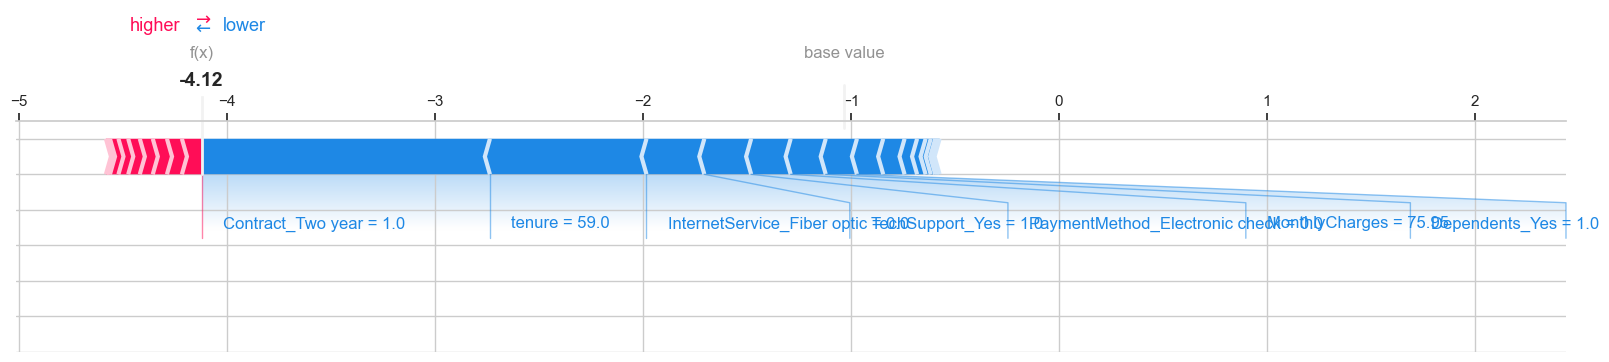

In [96]:
# ==========================================
# 13. SHAP INTERPRETABILITY
# ==========================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure X_test is still a DataFrame with column names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Use the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_df)

# -------------------------------
# A) SHAP Summary Plot (Top 15)
# -------------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot - Top 15 Features")
plt.tight_layout()
plt.show()

# -------------------------------
# B) Mean Absolute SHAP Bar Plot
# -------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_n = 15
top_idx = np.argsort(mean_abs_shap)[-top_n:]

plt.figure(figsize=(10, 7))
plt.barh(
    X_test_df.columns[top_idx],
    mean_abs_shap[top_idx]
)
plt.title("Top 15 Most Important Features Based on SHAP Values")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -------------------------------
# C) Optional: Local explanation
# -------------------------------
sample_index = 0

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test_df.iloc[sample_index],
    matplotlib=True
)
plt.show()

### 14.Save Model

In [97]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved successfully")
os.listdir("../models")# to check it is working or not


Model and scaler saved successfully


['best_model.pkl', 'scaler.pkl']

### 15.Business Recommendation and Insights

### Key Drivers of Churn
- Month-to-month contracts
- High monthly charges
- Low tenure customers
- Fiber optic internet users

### Business Recommendations
- Incentivize long-term contracts
- Target customers in first 6 months
- Provide loyalty discounts for high-paying users
- Improve fiber customer experience


## Limitations

There are several limitations to this project. The dataset is limited to a single telecommunications company, which means the results may not generalise to other industries or organisations.

The model is also dependent on the available features, and important factors such as customer satisfaction or external influences are not included in the dataset. This may reduce the model’s ability to fully explain customer churn behaviour.

Additionally, while advanced models such as XGBoost can improve performance, they are more complex and may be harder to interpret without additional tools such as SHAP.

Finally, the model is not implemented in a real-time system, and further work would be required to deploy it in a real business environment.